<a href="https://colab.research.google.com/github/ahirjaydeep/AI-Vision-Classifier/blob/feature%2Fmobilenet-model-architecture/notebooks/Model_Architecture_and_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Neural Network Architecture & Evaluation
**Role:** Machine Learning Engineer
**Objective:** Leverage transfer learning (MobileNetV2) to engineer a high-accuracy vision model. Implement a two-phase training protocol (frozen base followed by fine-tuning) and evaluate performance metrics.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import kagglehub
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_dir = os.path.join(path, "raw-img")

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory(data_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", subset="training")
val_gen = datagen.flow_from_directory(data_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", subset="validation")

# Map
class_names_it = sorted(os.listdir(data_dir))
class_names_en = ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
global_class_map = dict(zip(class_names_it, class_names_en))

Using Colab cache for faster access to the 'animals10' dataset.
Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.


## Phase 1 Architecture: Feature Extraction
Using MobileNetV2 as the base, freezing its weights, and adding a custom dense classification head tailored to our 10 target classes.

In [ ]:
# 1. Load Pretrained Base
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# 2. Architect Custom Head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print("Phase 1 Architecture Compiled.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1 Architecture Compiled.


## Phase 1 Training & Metric Visualization
Training the custom head and plotting the loss/accuracy curves to verify the model is learning without overfitting.

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 187s 256ms/step - accuracy: 0.9125 - loss: 0.2883 - val_accuracy: 0.9492 - val_loss: 0.1640
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 58s 89ms/step - accuracy: 0.9456 - loss: 0.1748 - val_accuracy: 0.9557 - val_loss: 0.1474
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 58s 88ms/step - accuracy: 0.9567 - loss: 0.1403 - val_accuracy: 0.9564 - val_loss: 0.1441
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 59s 89ms/step - accuracy: 0.9614 - loss: 0.1207 - val_accuracy: 0.9520 - val_loss: 0.1545
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 59s 89ms/step - accuracy: 0.9656 - loss: 0.1056 - val_accuracy: 0.9536 - val_loss: 0.1572
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - accuracy: 0.9707 - loss: 0.0891 - val_accuracy: 0.9534 - val_loss: 0.1674
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - accuracy: 0.9724 - loss: 0.0833 - val_accuracy: 0.9547 - val_loss: 0.1515
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - accuracy: 0.9754 - loss: 0.0724 

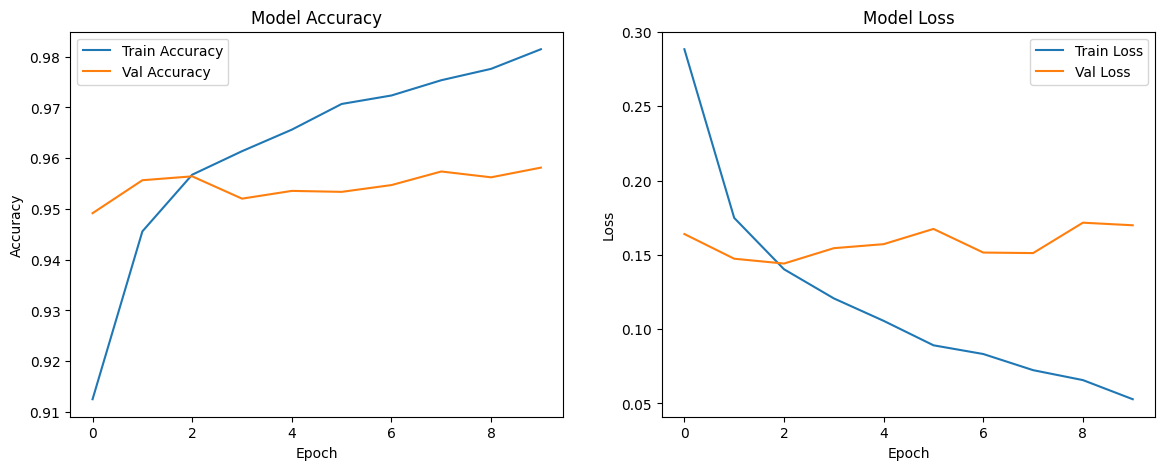

In [ ]:
# Train Model
history = model.fit(train_gen, validation_data=val_gen, epochs=10, verbose=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

## Phase 2: Fine-Tuning the Base Model
Unfreezing the top 50 layers of MobileNetV2 and compiling with a micro-learning rate to adjust the pre-trained weights specifically for our dataset.

In [ ]:
# Unfreeze base model
base_model.trainable = True

# Freeze all but the last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with very low learning rate
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("Phase 2: Fine-Tuning Commencing...")
history_fine = model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)

model.save("vision_classifier_v1.h5")
print("Model saved successfully as vision_classifier_v1.h5")

Phase 2: Fine-Tuning Commencing...
Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 103s 123ms/step - accuracy: 0.9335 - loss: 0.2426 - val_accuracy: 0.9557 - val_loss: 0.1959
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 61s 93ms/step - accuracy: 0.9598 - loss: 0.1228 - val_accuracy: 0.9606 - val_loss: 0.1796
Epoch 3/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 64s 98ms/step - accuracy: 0.9696 - loss: 0.0980 - val_accuracy: 0.9583 - val_loss: 0.1731
Epoch 4/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 63s 96ms/step - accuracy: 0.9739 - loss: 0.0775 - val_accuracy: 0.9608 - val_loss: 0.1603
Epoch 5/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 62s 94ms/step - accuracy: 0.9789 - loss: 0.0646 - val_accuracy: 0.9622 - val_loss: 0.1520


Model saved successfully as vision_classifier_v1.h5


In [ ]:
model.save("Zenity_Vision_Classifier.keras")